# Catalog backends: raster, xarray, vector

Three builders share one `GeoCatalog` shape. This notebook builds a
small catalog for each and prints the underlying data structure so
you can see what each backend records.

In [1]:
import tempfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import shapely.geometry
import xarray as xr
from rasterio.transform import from_bounds

import geotoolz as gz


tmp = Path(tempfile.mkdtemp(prefix="geotoolz_backends_"))
print(f"workdir: {tmp}")

workdir: /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geotoolz_backends_fxk1ktt5


## 1. Raster backend

The canonical case: a directory of GeoTIFFs, indexed by filename date.

In [2]:
def write_tif(name: str, value: int, bounds: tuple, crs: str = "EPSG:32629") -> Path:
    path = tmp / name
    xmin, ymin, xmax, ymax = bounds
    transform = from_bounds(xmin, ymin, xmax, ymax, 32, 32)
    data = np.full((3, 32, 32), value, dtype=np.uint16)
    with rasterio.open(
        path,
        "w",
        driver="GTiff",
        height=32,
        width=32,
        count=3,
        dtype="uint16",
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(data)
    return path


raster_files = [
    write_tif(
        "S2_T29SND_20240115_r0.tif", 10, (500_000, 4_000_000, 500_320, 4_000_320)
    ),
    write_tif(
        "S2_T29SND_20240116_r0.tif", 20, (500_320, 4_000_000, 500_640, 4_000_320)
    ),
]
raster_cat = gz.build_raster_catalog(
    raster_files,
    filename_regex=r"S2_T29SND_(?P<date>\d{8}).*\.tif",
    target_crs="EPSG:32629",
)
print(raster_cat)
print(f"backend: {raster_cat.backend}")

InMemoryGeoCatalog(backend='raster', len=2, crs=<Projected CRS: EPSG:32629>
Name: WGS 84 / UTM zone 29N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°W and 6°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Côte D'Ivoire (Ivory Coast). Faroe Islands. Guinea. Ireland. Jan Mayen. Liberia, Mali. Mauritania. Morocco. Portugal. Sierra Leone. Spain. United Kingdom (UK). Western Sahara.
- bounds: (-12.01, 0.0, -6.0, 84.01)
Coordinate Operation:
- name: UTM zone 29N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
backend: raster


The catalog is literally a `GeoDataFrame` — show it.

In [3]:
raster_cat.gdf

,filepath,geometry,start_time,end_time,crs
datetime,,,,,
"[2024-01-15 00:00:00, 2024-01-15 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((500320 4000000, 500320 4000320, 5000...",2024-01-15,2024-01-15 23:59:59.999999,EPSG:32629
"[2024-01-16 00:00:00, 2024-01-16 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((500640 4000000, 500640 4000320, 5003...",2024-01-16,2024-01-16 23:59:59.999999,EPSG:32629


## 2. Xarray backend (extras: `xarray-raster`)

A small NetCDF on disk; bounds come from the coord min/max, time from
a configurable coordinate (default `"time"`).

In [4]:
nc_path = tmp / "modis_2024.nc"
ds = xr.Dataset(
    {
        "ndvi": (
            ("time", "y", "x"),
            np.linspace(0, 1, 5 * 16 * 16, dtype=np.float32).reshape(5, 16, 16),
        )
    },
    coords={
        "time": pd.date_range("2024-01-01", periods=5, freq="D"),
        "y": np.linspace(40.5, 40.0, 16),
        "x": np.linspace(-3.5, -3.0, 16),
    },
)
ds.to_netcdf(nc_path)
print("Original xarray.Dataset:")
print(ds)

Original xarray.Dataset:
<xarray.Dataset> Size: 5kB
Dimensions:  (time: 5, y: 16, x: 16)
Coordinates:
  * time     (time) datetime64[us] 40B 2024-01-01 2024-01-02 ... 2024-01-05
  * y        (y) float64 128B 40.5 40.47 40.43 40.4 ... 40.1 40.07 40.03 40.0
  * x        (x) float64 128B -3.5 -3.467 -3.433 -3.4 ... -3.067 -3.033 -3.0
Data variables:
    ndvi     (time, y, x) float32 5kB 0.0 0.0007819 0.001564 ... 0.9992 1.0


In [5]:
xa_cat = gz.build_xarray_catalog(
    [nc_path], target_crs="EPSG:4326", data_vars=["ndvi"], time_var="time"
)
print(xa_cat)
print(f"backend: {xa_cat.backend}")
print(f"n_timesteps: {int(xa_cat.gdf['n_timesteps'].iloc[0])}")
xa_cat.gdf

InMemoryGeoCatalog(backend='xarray', len=1, crs=<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
backend: xarray
n_timesteps: 5


,filepath,geometry,start_time,end_time,n_timesteps,time_var,data_vars,crs
datetime,,,,,,,,
"[2024-01-01 00:00:00, 2024-01-05 00:00:00]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((-3 40, -3 40.5, -3.5 40.5, -3.5 40, ...",2024-01-01,2024-01-05,5,time,[ndvi],EPSG:4326


## 3. Vector backend

Polygon footprints come from each file's `total_bounds` in the target
CRS. Loaders rasterise into a label `GeoTensor` for ML targets.

In [6]:
vec_gdf = gpd.GeoDataFrame(
    {
        "class_id": [1, 2],
        "geometry": [
            shapely.geometry.box(500_000, 4_000_000, 500_160, 4_000_160),
            shapely.geometry.box(500_160, 4_000_160, 500_320, 4_000_320),
        ],
    },
    crs="EPSG:32629",
)
vec_path = tmp / "labels_20240115.gpkg"
vec_gdf.to_file(vec_path, driver="GPKG")

print("Original GeoDataFrame on disk:")
print(vec_gdf)

Original GeoDataFrame on disk:


   class_id                                           geometry
0         1  POLYGON ((500160 4000000, 500160 4000160, 5000...
1         2  POLYGON ((500320 4000160, 500320 4000320, 5001...


In [7]:
vec_cat = gz.build_vector_catalog(
    [vec_path], filename_regex=r"labels_(?P<date>\d{8})\.gpkg"
)
print(vec_cat)
print(f"backend: {vec_cat.backend}")
vec_cat.gdf

InMemoryGeoCatalog(backend='vector', len=1, crs=<Projected CRS: EPSG:32629>
Name: WGS 84 / UTM zone 29N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°W and 6°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Côte D'Ivoire (Ivory Coast). Faroe Islands. Guinea. Ireland. Jan Mayen. Liberia, Mali. Mauritania. Morocco. Portugal. Sierra Leone. Spain. United Kingdom (UK). Western Sahara.
- bounds: (-12.01, 0.0, -6.0, 84.01)
Coordinate Operation:
- name: UTM zone 29N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
backend: vector


,filepath,geometry,start_time,end_time,layer
datetime,,,,,
"[2024-01-15 00:00:00, 2024-01-15 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((500320 4000000, 500320 4000320, 5000...",2024-01-15,2024-01-15 23:59:59.999999,None


## Rasterising the labels for an AOI

label_tensor.values.shape: (1, 32, 32)   # (1, 32, 32)
unique class IDs: [0, 1, 2]


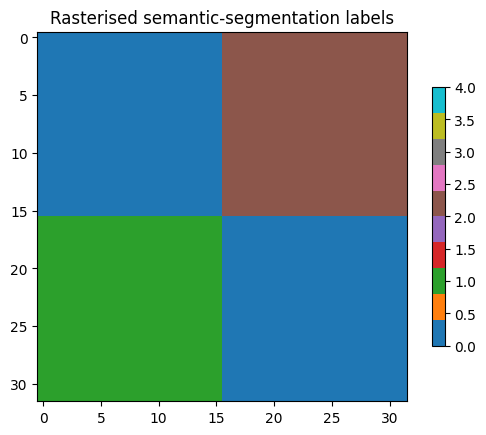

In [8]:
aoi = gz.GeoSlice(
    bounds=(500_000, 4_000_000, 500_320, 4_000_320),
    interval=pd.Interval(
        pd.Timestamp("2024-01-15"), pd.Timestamp("2024-01-16"), closed="both"
    ),
    resolution=(10.0, 10.0),
    crs="EPSG:32629",
)
label_tensor = gz.load_vector(
    vec_cat, aoi, task="semantic_segmentation", label_field="class_id"
)
print(f"label_tensor.values.shape: {label_tensor.values.shape}   # (1, 32, 32)")
print(f"unique class IDs: {sorted(np.unique(label_tensor.values).tolist())}")

plt.imshow(label_tensor.values[0], cmap="tab10", vmin=0, vmax=4)
plt.title("Rasterised semantic-segmentation labels")
plt.colorbar(shrink=0.7)
plt.show()

## GeoParquet roundtrip

Any catalog can be persisted as a GeoParquet artifact. The Phase 2
DuckDB backend reads the same format.

In [9]:
parquet_path = tmp / "raster_cat.parquet"
gz.to_geoparquet(raster_cat, parquet_path)
print(f"wrote {parquet_path.stat().st_size} bytes to {parquet_path}")

recovered = gz.from_geoparquet(parquet_path)
print(f"recovered: {recovered}")
print(f"len matches: {len(recovered) == len(raster_cat)}")

wrote 17871 bytes to /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geotoolz_backends_fxk1ktt5/raster_cat.parquet


recovered: InMemoryGeoCatalog(backend='raster', len=2, crs=<Projected CRS: EPSG:32629>
Name: WGS 84 / UTM zone 29N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°W and 6°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Côte D'Ivoire (Ivory Coast). Faroe Islands. Guinea. Ireland. Jan Mayen. Liberia, Mali. Mauritania. Morocco. Portugal. Sierra Leone. Spain. United Kingdom (UK). Western Sahara.
- bounds: (-12.01, 0.0, -6.0, 84.01)
Coordinate Operation:
- name: UTM zone 29N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
)
len matches: True
